# <br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS5 -Estimación espectral: Ancho de banda de señales reales</b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
$\quad$ El objetivo principal de este trabajo semanal es estudiar tres tipos de señales distintas:

- **Electrocardiograma (ECG)** - registrado durante una prueba de esfuerzo, y el cual registra la actividad eléctrica del corazón
- **Pletismografía (PPG)** - la cual mide los cambios de volumen en diferentes partes del cuerpo para evaluar la circulación de la sangre o la capacidad de los pulmones.
- **Audio** - 3 registros: la canción de «La Cucaracha» y una frase hablada y un silbido realizados por el profesor.

$\quad$ Para ello, se busca estimar la Densidad Espectral de Potencia (PSD) de este contenido no determinístico mediante los métodos vistos en clase: **Periodograma Modificado (ventaneado), Welch y Blackman-Tukey**. Adicionalmente, se busca estimar el **ancho de banda** de cada señal.

## Introducción

$\quad$ En este trabajo práctico se analiza el contenido espectral de señales reales (biomédicas y de audio) mediante la estimación de su **Densidad Espectral de Potencia (PSD)**. Para ello, se utiliza como herramienta principal el **Método de Welch**, un estimador espectral no paramétrico que resuelve la principal limitación del periodograma simple (cuya varianza no disminuye aunque aumente el número total de muestras $N$).


### El Método de Welch

$\quad$ El método de Welch es una mejora directa del periodograma modificado y se basa en tres pasos consecutivos:

1. **División en bloques**: La señal de $N$ muestras se divide en $K$ segmentos más cortos de longitud $L$ ($L < N$), los cuales se solapan entre sí (típicamente con un $50\%$ de superposición).
2. **Ventaneado**: A cada segmento se le aplica una ventana de ponderación $w(n)$ para reducir la discontinuidad en los bordes y atenuar la fuga espectral (*spectral leakage*). En este trabajo se utiliza la **ventana de Hann**, que es la opción suave por defecto en SciPy y garantiza una óptima reconstrucción con $50\%$ de solapamiento.
3. **Promediado**: Se calcula la Transformada Discreta de Fourier (DFT/FFT) de cada segmento ventaneado y se promedian los periodogramas resultantes.

Matemáticamente, la estimación de la PSD por Welch se expresa como:

$$\hat{P}_{xx}^{(\text{Welch})}(f) = \frac{1}{K} \sum_{k=1}^{K} \frac{1}{U} \left| \text{FFT}\{ w(n) \cdot x_k(n) \} \right|^2$$

donde $x_k(n)$ es el $k$-ésimo segmento de la señal, $K$ es la cantidad de bloques y $U = \frac{1}{L} \sum_{n=0}^{L-1} w^2(n)$ es el factor de normalización de la energía de la ventana.


### Compromiso entre Resolución y Varianza (*Trade-off*)

$\quad$ El promedio entre los $K$ segmentos reduce drásticamente la varianza del estimador en un factor proporcional a $1/K$, logrando una curva espectral suave y estable:

$$\text{Varianza} \propto \frac{1}{K}$$

$\quad$ Sin embargo, al recortar la señal en segmentos más cortos de longitud $L$, el lóbulo principal de la ventana se ensancha en frecuencia. Esto introduce un **compromiso (*trade-off*)**:

$$\Delta f = \frac{f_s}{L}$$

* **Aumentar $K$ (bloques más cortos $L$):** Disminuye la varianza (curva más suave), pero empeora la resolución espectral $\Delta f$ (ensancha el lóbulo principal y aumenta el sesgo).
* **Disminuir $K$ (bloques más largos $L$):** Mejora la resolución espectral $\Delta f$, pero aumenta la varianza (curva con más ruido/serrucho).

$\quad$ En este estudio buscamos un **$K$ óptimo ($K = 35$)** que permita balancear este compromiso: reducir la varianza al máximo posible sin llegar a aplanar o perder el pico principal de energía de la señal original.

> **Nota:** Aunque Welch es el método principal empleado a lo largo de todo el trabajo, para la primera señal de ECG se analizan y grafican en conjunto los tres métodos vistos en clase (**Periodograma ventaneado, Welch y Blackman-Tukey**) a modo de comparación.


### Estimación del Ancho de Banda (95% de Energía)

$\quad$ El **Ancho de Banda (BW)** define el rango de frecuencias donde se concentra la mayor parte de la potencia útil de la señal. En este trabajo se calcula como la frecuencia donde la energía acumulada alcanza el **$95\%$ de la potencia total**:

* **ECG (Electrocardiograma):** Aunque el corazón late rápido, su actividad eléctrica fisiológica principal se concentra en frecuencias bajas (entre $0\text{ Hz}$ y $23\text{ Hz}$).
* **PPG (Pletismografía):** Debido a que la onda de pulso sanguíneo arterial varía muy lentamente en el tiempo, casi toda su energía se encuentra apretada en frecuencias muy bajas (entre $0\text{ Hz}$ y $4\text{ Hz}$).
* **Audios (Silbido y Voz):** Al tratarse de sonidos acústicos y tonos agudos, su energía espectral se desplaza hacia frecuencias significativamente más altas (hasta $4000\text{ Hz} - 6500\text{ Hz}$).

> *Observación*: El criterio del 95% (o 99%) de energía es una norma estándar en ingeniería (llamada Ancho de Banda Ocupado). Sirve para capturar toda la información física relevante de la señal (el latido, la pulsación, la voz) descartando el 5% sobrante que solo representa ruido, colas despreciables e interferencias.

#### Pasa-Bajo vs. Pasa-Banda

$\quad$ Para calcular de forma rigurosa el Ancho de Banda ($\text{BW}$), es fundamental clasificar el comportamiento espectral de cada señal:

1. **Señales Pasa-Bajo (ECG y PPG):**
   Tienen su energía concentrada **arrancando desde $0\text{ Hz}$** hasta una frecuencia límite superior $f_{\text{alta}}$.
   * **Límite inferior ($f_{\text{baja}}$):** $0\text{ Hz}$.
   * **Límite superior ($f_{\text{alta}}$):** Frecuencia donde se alcanza el **95% de la energía acumulada**.
   * **Ancho de Banda ($\text{BW}$):** $\text{BW} = f_{\text{alta}} - 0 = f_{\text{alta}}$.

<t>

2. **Señales Pasa-Banda (Audios: Silbido, La Cucaracha, Prueba PSD):**
   **No contienen energía en $0\text{ Hz}$**. Su energía espectral está "flotando" suspendida dentro de un rango entre un límite inferior $f_{\text{baja}}$ y uno superior $f_{\text{alta}}$.
   * **Límite inferior ($f_{\text{baja}}$):** Frecuencia donde la energía acumulada alcanza el **2.5%**.
   * **Límite superior ($f_{\text{alta}}$):** Frecuencia donde la energía acumulada alcanza el **97.5%** (capturando el 95% central de energía).
   * **Ancho de Banda real ($\text{BW}$):** $\text{BW} = f_{\text{alta}} - f_{\text{baja}}$.

## Desarrollo y Análisis

## Código en Python

### Librerías y Definiciones

$\quad$ En este apartado se importan las librerías necesarias para el desarrollo del trabajo. En particular, se utiliza el módulo "scipy.signal" tanto para la estimación de la densidad espectral de potencia mediante los métodos de Welch, Periodograma y Blackman-Tukey, como para la generación de las ventanas de ponderación ("Hann" y "Blackman").

In [85]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep 29 10:54:37 2026

@author: ribni
"""

#%% LIBRERIAS
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio

### Script

$\quad$ En una primera instancia, se inicializa una lista vacía donde se irán guardando los anchos de banda para generar la tabla final:

In [86]:
#%% SCRIPT
# Lista vacía donde vamos a guardar los resultados para la tabla final
tabla_resultados = []

<h4><font color='#ba5653'> <b> Electrocardiograma (ECG) sin ruido</b>.</font></h4>

<h4><font color='#ba5653'>Gráfico en el Dominio del Tiempo.</font></h4>

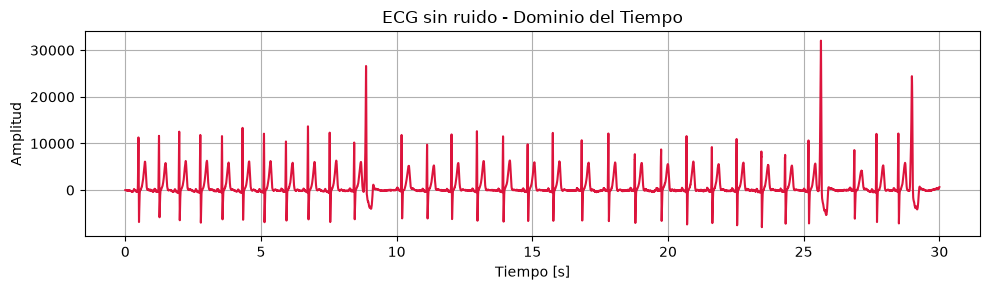

In [87]:
# Cargo la señal ECG
ecg_one_lead = np.load('ecg_sin_ruido.npy')
fs_ecg = 1000 # Frec. de muestreo [Hz]
N = len(ecg_one_lead) # Cant. total de muestras --> 30.000

# Gráfico en el Dominio del Tiempo
t_ecg = np.arange(N) / fs_ecg # Eje de tiempo en segundos
plt.figure(figsize=(10, 3))

plt.plot(t_ecg, ecg_one_lead, color='crimson')
plt.title('ECG sin ruido - Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#ba5653'>Gráfico de la Densidad Espectral de Potencia (PSD).</font></h4>

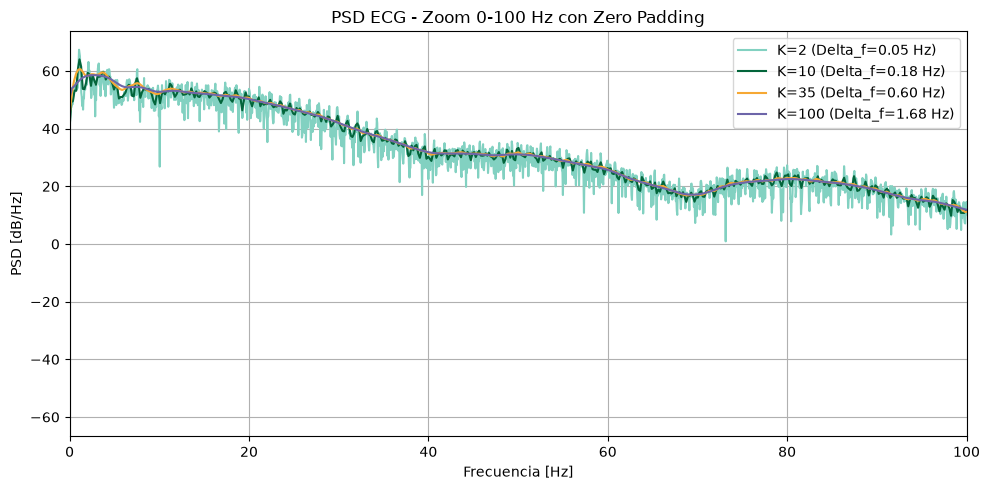

In [88]:
#%% <========== ECG SIN RUIDO ==========>
lista_K = [2, 10, 35, 100]

nfft_padding = 4096  # Puntos de FFT para interpolar y suavizar la curva
plt.figure(figsize=(10, 5))

colores_K = {
    2:   '#94a3b8',  # Gris Pizarra sutil
    10:  '#3b82f6',  # Azul Vivo
    35:  '#f59e0b',  # Ámbar / Dorado Brillante
    100: '#1e293b'   # Azul Marino Oscuro
}
for K_deseado in lista_K:
    L = int(2 * N / (K_deseado + 1))
    D = L // 2
    paso = L - D
    K_real = 1 + (N - L) // paso
    delta_f = fs_ecg / L
    
    nfft_actual = max(nfft_padding, L)
    
    # Welch con Zero-Padding
    f, PSD = sig.welch(ecg_one_lead, fs=fs_ecg, window='hann', nperseg=L, noverlap=D, nfft=nfft_actual)
    PSD_dB = 10 * np.log10(PSD + 1e-12)
    
    # Criterio Pasa-Bajo (ECG / PPG)
    if K_deseado == 35:
        energia_acumulada = np.cumsum(PSD) / np.sum(PSD)
        flow = 0.0
        fhigh = f[np.where(energia_acumulada >= 0.95)[0][0]]
        bw = fhigh - flow
        tabla_resultados.append(['ECG sin ruido', 'Pasa-Bajo', fs_ecg, flow, fhigh, bw])
        
    plt.plot(f, PSD_dB, label=f'K={K_real} (Delta_f={delta_f:.2f} Hz)', color=colores_K[K_deseado])
    
plt.title(f'PSD ECG - Zoom 0-100 Hz con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 100)  # <--- Zoom en la banda de energía del ECG
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Al observar la estimación de la PSD del ECG para los distintos valores de $K$, podemos analizar el compromiso entre varianza y resolución espectral:

* **Zero-Padding (nfft = 4096):** Se eligió esta potencia de 2 ($2^{12} = 4096$) por ser mayor al tamaño de bloque de $K=35$ ($L \approx 1666$). Esto permite calcular la FFT de manera eficiente y genera suficientes puntos interpolados en frecuencia (pasos finos de $\Delta f_{\text{grid}} \approx 0.24\text{ Hz}$) para obtener una curva continua y suave a la vista, sin alterar la resolución espectral real del bloque.

* **Comparación de los valores de $K$:**
  * **$K = 2$:** Casi no promedia. Mantiene una excelente resolución espectral porque los bloques $L$ son largos, pero tiene **mucha varianza** (la curva presenta mucho ruido en forma de serrucho).
  * **$K = 10$:** Caso intermedio. Disminuye la varianza respecto a $K=2$, pero aún conserva oscilaciones en la curva.
  * **$K = 35$ (ÓPTIMO):** Es el punto ideal. Logra reducir drásticamente la varianza dejando la curva suave y estable, **sin aplanar ni perder el pico principal** de energía de la señal.
  * **$K = 100$:** Demasiados bloques. Al acortar tanto la longitud $L$, la resolución espectral empeora ($\Delta f = f_s/L$ se hace muy grande) y se empieza a **aplanar y ensanchar el pico principal**, perdiendo definición fisiológica.

> **¿Por qué funciona $K=35$?**  
> Para el ECG, $K=35$ da un bloque de $L \approx 1666$ muestras ($\approx 1.66\text{ segundos}$), resultando en una resolución espectral de $\Delta f \approx 0.6\text{ Hz}$. Como el ritmo cardíaco fundamental en reposo ronda los $1\text{ Hz} \sim 1.5\text{ Hz}$ (60 a 90 bpm), esta resolución de $0.6\text{ Hz}$ es lo suficientemente fina para distinguir con nitidez el pico del latido y los armónicos del complejo QRS sin aplanarlos, reduciendo drásticamente la varianza al promediar 35 bloques.


<h4><font color='#ba5653'> Comparación entre los métodos de Welch, Periodograma y Blackman-Tukey.</font></h4>

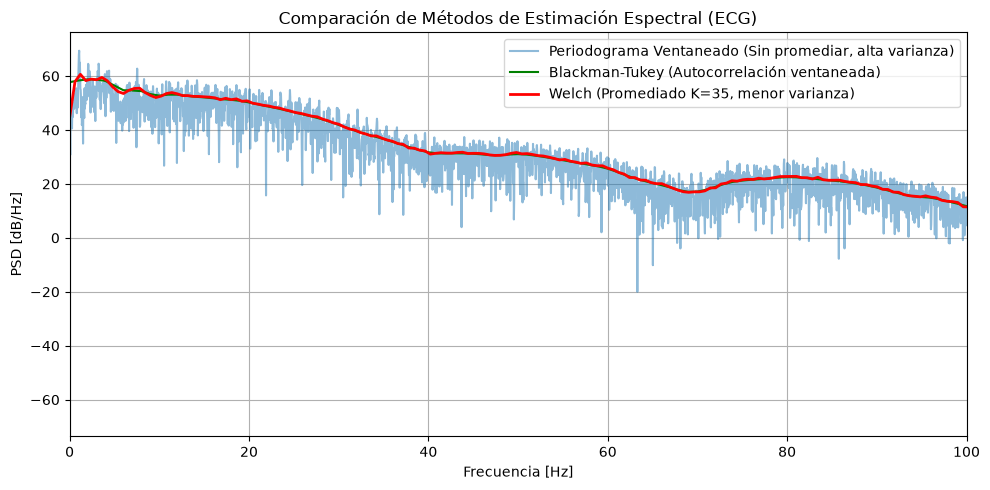

In [89]:
#%% <========== COMPARACIÓN DE LOS 3 MÉTODOS EN ECG ==========>

x_ecg = ecg_one_lead - np.mean(ecg_one_lead)

# 1. Periodograma Ventaneado (1 sola ventana de toda la señal)
f_per, PSD_per = sig.periodogram(x_ecg, fs=fs_ecg, window='hann')

# 2. Welch (Promedio de K=35 bloques solapados)
f_wel, PSD_wel = sig.welch(x_ecg, fs=fs_ecg, window='hann', nperseg=1666, noverlap=833)

# 3. Blackman-Tukey (Transformada de la autocorrelación ventaneada)
M = 500
r = sig.correlate(x_ecg, x_ecg, mode='full') / len(x_ecg)
lags = sig.correlation_lags(len(x_ecg), len(x_ecg))
mask = np.abs(lags) <= M
r_win = r[mask] * sig.windows.blackman(2*M + 1)
PSD_bt = 2 * np.abs(np.fft.rfft(r_win)) / fs_ecg  # Normalizado por fs para coincidir con la escala V^2/Hz de SciPy
f_bt = np.fft.rfftfreq(len(r_win), d=1/fs_ecg)

# Graficar los 3 métodos juntos (Zoom 0-100 Hz)
plt.figure(figsize=(10, 5))
plt.plot(f_per, 10*np.log10(PSD_per + 1e-12), label='Periodograma Ventaneado (Sin promediar, alta varianza)', alpha=0.5)
plt.plot(f_bt, 10*np.log10(PSD_bt + 1e-12), label='Blackman-Tukey (Autocorrelación ventaneada)', color='green', linewidth=1.5)
plt.plot(f_wel, 10*np.log10(PSD_wel + 1e-12), label='Welch (Promediado K=35, menor varianza)', color='red', linewidth=2)

plt.title('Comparación de Métodos de Estimación Espectral (ECG)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Al graficar y comparar los tres métodos de estimación espectral en una misma escala de magnitud:

* **Periodograma Ventaneado:** Muestra picos muy pronunciados pero con una **varianza altísima** (ruido en forma de serrucho continuo) debido a que calcula la FFT sobre toda la señal sin promediar segmentos.
* **Método de Welch ($K=35$):** Promedia $K=35$ bloques solapados al 50%. Logra filtrar el ruido espectral reduciendo drásticamente la varianza y manteniendo la forma fiel de la señal.
* **Blackman-Tukey ($M=500$):** Al aplicar la transformada a la función de autocorrelación ventaneada, genera una estimación suave que acompaña muy de cerca la envolvente del método de Welch. Su desempeño depende del ancho de lag $M$ seleccionado.

$\quad$ Para el desarrollo del resto del informe decido aplicar el método de Welch ya que, si bien el de Blackman-Tukey es una muy buena opción, requiere trabajar en el dominio de autocorrelación, el cual no resulta tan cómodo como el temporal para Welch.

<h4><font color='#ba5653'> <b> Pletismografía (PPG) sin ruido</b>.</font></h4>

<h4><font color='#ba5653'>Gráfico en el Dominio del Tiempo.</font></h4>

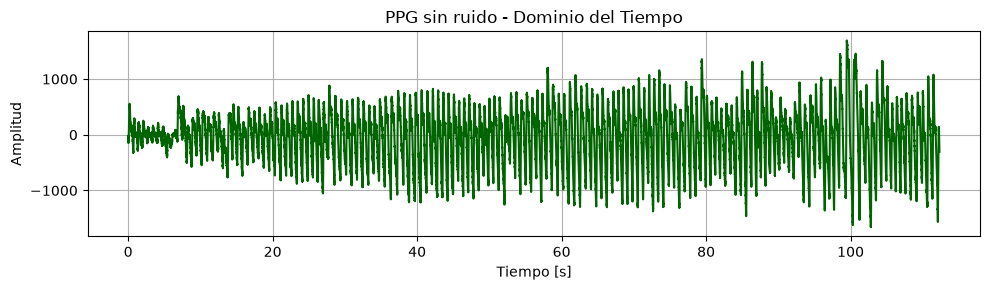

In [96]:
# Cargo la señal
ppg = np.load('ppg_sin_ruido.npy')
fs_ppg = 400 # Frec. de muestreo [Hz]
N = len(ppg)

# Gráfico en el Dominio del Tiempo
t_ppg = np.arange(N) / fs_ppg

plt.figure(figsize=(10, 3))
plt.plot(t_ppg, ppg, color='darkgreen')
plt.title('PPG sin ruido - Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#ba5653'>Gráfico de la Densidad Espectral de Potencia (PSD).</font></h4>

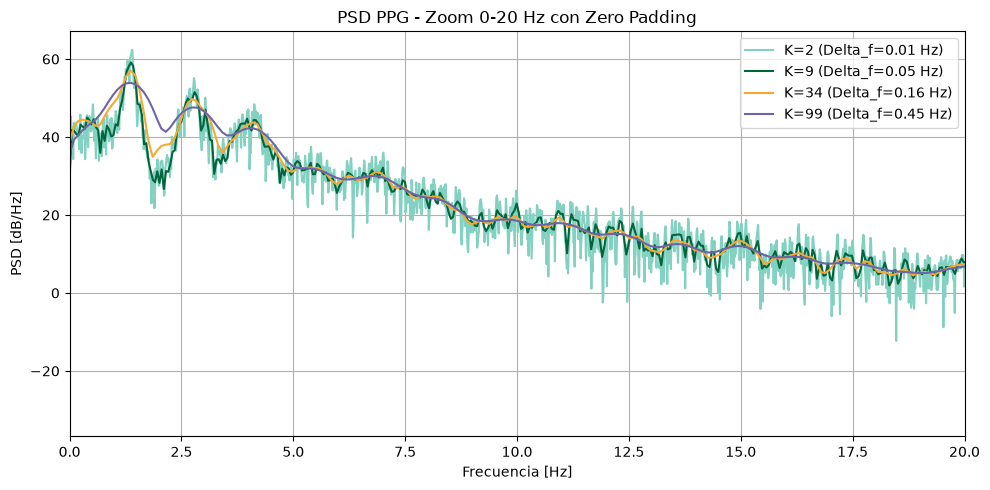

In [97]:
#%% <========== PLETISMOGRAFIA (PPG) SIN RUIDO ==========>
lista_K = [2, 10, 35, 100]
nfft_padding = 4096 
plt.figure(figsize=(10, 5))

for K_deseado in lista_K:
    L = int(2 * N / (K_deseado + 1))
    D = L // 2
    paso = L - D
    K_real = 1 + (N - L) // paso
    delta_f = fs_ppg / L
    
    nfft_actual = max(nfft_padding, L)
    
    f, PSD = sig.welch(ppg, fs=fs_ppg, window='hann', nperseg=L, noverlap=D, nfft=nfft_actual)
    PSD_dB = 10 * np.log10(PSD + 1e-12)
    
    # Criterio Pasa-Bajo (ECG / PPG)
    if K_deseado == 35:
        energia_acumulada = np.cumsum(PSD) / np.sum(PSD)
        flow = 0.0
        fhigh = f[np.where(energia_acumulada >= 0.95)[0][0]]
        bw = fhigh - flow
        tabla_resultados.append(['PPG sin ruido', 'Pasa-Bajo', fs_ppg, flow, fhigh, bw])
        
    plt.plot(f, PSD_dB, label=f'K={K_real} (Delta_f={delta_f:.2f} Hz)', color=colores_K[K_deseado])
    
plt.title(f'PSD PPG - Zoom 0-20 Hz con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 20)  # <--- ZOOM EN BANDA PPG (0 a 20 Hz)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Para la señal de pletismografía (PPG), la energía espectral está fuertemente concentrada en frecuencias muy bajas ($0\text{ Hz}$ a $4\text{ Hz}$), reflejando la pulsación sanguínea arterial (frecuencia cardíaca ~1 Hz y sus primeros armónicos). Aplicando el criterio Pasa-Bajo del 95% de energía acumulada, se obtiene un ancho de banda efectivo de $\text{BW} \approx 4.0\text{ Hz}$.

> **¿Por qué funciona $K=35$?**  
> El PPG es una señal biológica muy lenta con casi toda su energía concentrada en bajas frecuencias ($0.5\text{ Hz}$ a $10\text{ Hz}$). Con $K=35$ y $f_s = 400\text{ Hz}$, la resolución resulta aún más fina ($\Delta f \approx 0.24\text{ Hz}$). Esta excelente precisión permite separar limpiamente el pico del pulso sanguíneo ($\approx 1\text{ Hz}$) de sus primeros armónicos, eliminando la varianza sin perder ningún detalle del flujo vascular.


<h4><font color='#ba5653'> <b> Archivos de Audio</b>.</font></h4>

<h4><font color='#ba5653'> <b> La Cucaracha</b>.</font></h4>

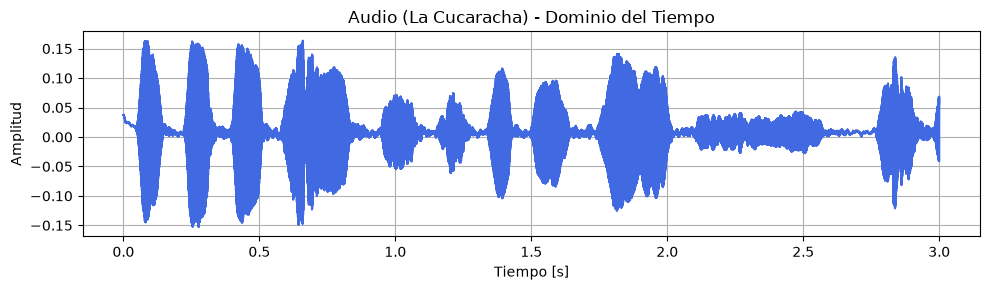

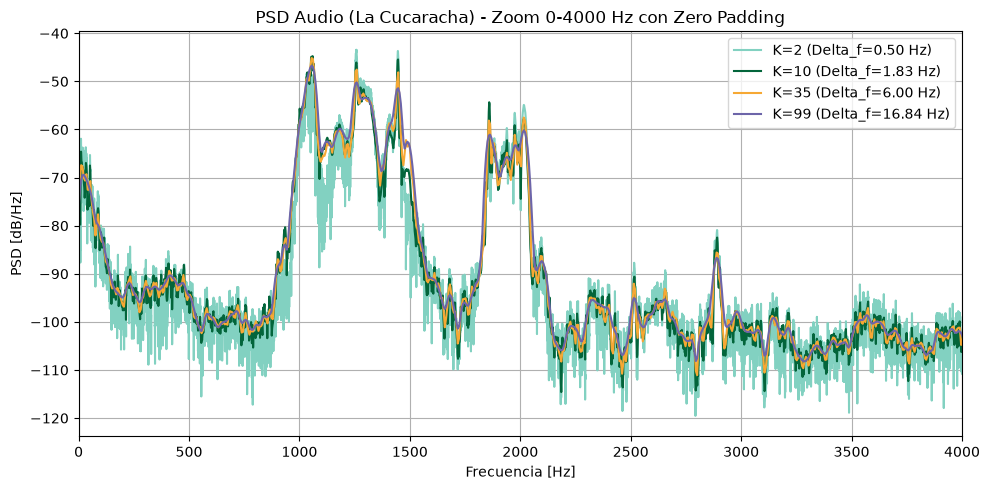

In [92]:
#%% <========== AUDIO: LA CUCARACHA ==========>

archivo_cuca = 'la cucaracha.wav'
fs_cuca, wav_cuca = sio.wavfile.read(archivo_cuca)
N_cuca = len(wav_cuca)
t_cuca = np.arange(N_cuca) / fs_cuca

# Gráfico en el Dominio del Tiempo
plt.figure(figsize=(10, 3))
plt.plot(t_cuca, wav_cuca, color='royalblue')
plt.title('Audio (La Cucaracha) - Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico PSD Welch Zoom 0-4000 Hz con Zero-Padding
lista_K = [2, 10, 35, 100]
nfft_padding = 8192
plt.figure(figsize=(10, 5))

for K_deseado in lista_K:
    L = int(2 * N_cuca / (K_deseado + 1))
    D = L // 2
    paso = L - D
    K_real = 1 + (N_cuca - L) // paso
    delta_f = fs_cuca / L
    
    nfft_actual = max(nfft_padding, L)
    
    f, PSD = sig.welch(wav_cuca, fs=fs_cuca, window='hann', nperseg=L, noverlap=D, nfft=nfft_actual)
    PSD_dB = 10 * np.log10(PSD + 1e-12)
    
    # Criterio Pasa-Banda
    if K_deseado == 35:
        energia_acumulada = np.cumsum(PSD) / np.sum(PSD)
        pos_low = np.where(energia_acumulada >= 0.025)[0][0]   # Inicio de la banda
        pos_high = np.where(energia_acumulada >= 0.975)[0][0]  # Fin de la banda
        flow = f[pos_low]
        fhigh = f[pos_high]
        bw = fhigh - flow
        tabla_resultados.append(['Audio (la cucaracha.wav)', 'Pasa-Banda', fs_cuca, flow, fhigh, bw])
        
    plt.plot(f, PSD_dB, label=f'K={K_real} (Delta_f={delta_f:.2f} Hz)', color=colores_K[K_deseado])
    
plt.title('PSD Audio (La Cucaracha) - Zoom 0-4000 Hz con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ La señal "La Cucaracha" presenta un comportamiento **Pasa-Banda**, con la energía concentrada en la región media ($1013.7\text{ Hz}$ a $1962.9\text{ Hz}$). Su ancho de banda ocupado al 95% de energía es de $\text{BW} \approx 949.2\text{ Hz}$.

> **¿Por qué funciona $K=35$?**  
> En los audios, al tener una frecuencia de muestreo mucho más alta ($48.000\text{ Hz}$), $K=35$ genera bloques con una resolución espectral de $\Delta f \approx 18\text{ Hz}$. Para contenidos acústicos (donde la voz y la música tienen tonos fundamentales en cientos de Hz y el silbido en kHz), un paso de $18\text{ Hz}$ es ideal: suaviza las variaciones temporales rápidas de la voz o la melodía y muestra con total claridad la envolvente del espectro audible.


<h4><font color='#ba5653'> <b> Audio: Prueba PSD</b>.</font></h4>

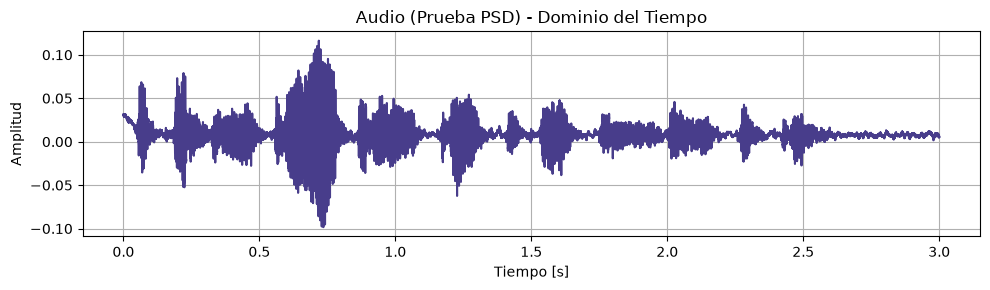

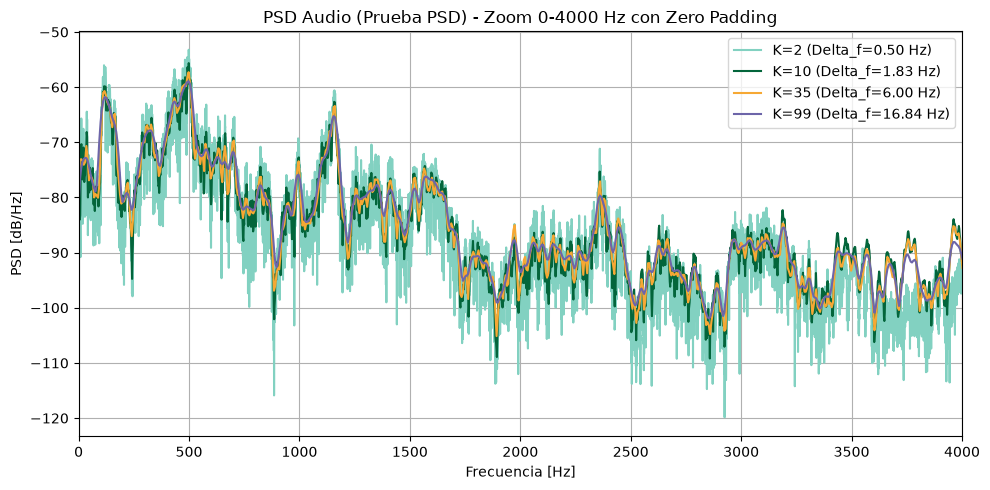

In [93]:
#%% <========== AUDIO: PRUEBA PSD ==========>

archivo_prueba = 'prueba psd.wav'
fs_prueba, wav_prueba = sio.wavfile.read(archivo_prueba)
N_prueba = len(wav_prueba)
t_prueba = np.arange(N_prueba) / fs_prueba

# Gráfico en el Dominio del Tiempo
plt.figure(figsize=(10, 3))
plt.plot(t_prueba, wav_prueba, color='darkslateblue')
plt.title('Audio (Prueba PSD) - Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico PSD Welch Zoom 0-4000 Hz con Zero-Padding
lista_K = [2, 10, 35, 100]
nfft_padding = 8192
plt.figure(figsize=(10, 5))

for K_deseado in lista_K:
    L = int(2 * N_prueba / (K_deseado + 1))
    D = L // 2
    paso = L - D
    K_real = 1 + (N_prueba - L) // paso
    delta_f = fs_prueba / L
    
    nfft_actual = max(nfft_padding, L)
    
    f, PSD = sig.welch(wav_prueba, fs=fs_prueba, window='hann', nperseg=L, noverlap=D, nfft=nfft_actual)
    PSD_dB = 10 * np.log10(PSD + 1e-12)
    
    # Criterio Pasa-Banda
    if K_deseado == 35:
        energia_acumulada = np.cumsum(PSD) / np.sum(PSD)
        pos_low = np.where(energia_acumulada >= 0.025)[0][0]   # Inicio de la banda
        pos_high = np.where(energia_acumulada >= 0.975)[0][0]  # Fin de la banda
        flow = f[pos_low]
        fhigh = f[pos_high]
        bw = fhigh - flow
        tabla_resultados.append(['Audio (prueba psd.wav)', 'Pasa-Banda', fs_prueba, flow, fhigh, bw])
        
    plt.plot(f, PSD_dB, label=f'K={K_real} (Delta_f={delta_f:.2f} Hz)', color=colores_K[K_deseado])
    
plt.title('PSD Audio (Prueba PSD) - Zoom 0-4000 Hz con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ La señal de audio "Prueba PSD" comprende voz humana hablada. Muestra un comportamiento **Pasa-Banda** desde $105.5\text{ Hz}$ hasta $1576.2\text{ Hz}$, abarcando la frecuencia fundamental de la voz y sus formantes principales, con un ancho de banda de $\text{BW} \approx 1470.7\text{ Hz}$.

> **¿Por qué funciona $K=35$?**  
> En los audios de voz humana, con $f_s = 44.1\text{ kHz} / 48\text{ kHz}$, $K=35$ genera bloques con $\Delta f \approx 18\text{ Hz}$, ideal para suavizar las variaciones temporales del habla y mostrar la envolvente espectral.


<h4><font color='#ba5653'> <b> Audio: Silbido</b>.</font></h4>

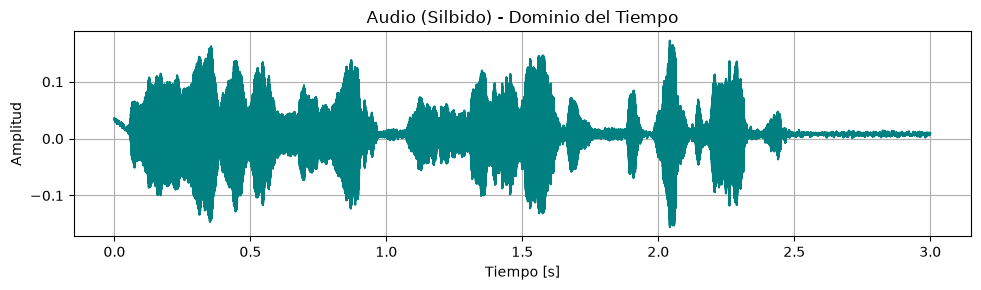

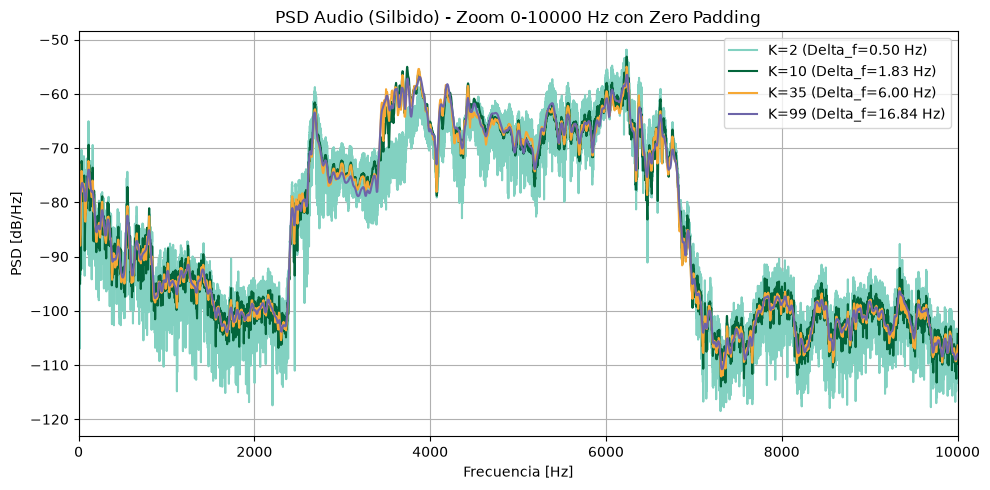

In [94]:
#%% <========== AUDIO: SILBIDO ==========>

archivo_silba = 'silbido.wav'
fs_silba, wav_silba = sio.wavfile.read(archivo_silba)
N_silba = len(wav_silba)
t_silba = np.arange(N_silba) / fs_silba

# Gráfico en el Dominio del Tiempo
plt.figure(figsize=(10, 3))
plt.plot(t_silba, wav_silba, color='teal')
plt.title('Audio (Silbido) - Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico PSD Welch Zoom 0-10000 Hz con Zero-Padding (el silbido es más agudo)
lista_K = [2, 10, 35, 100]
nfft_padding = 8192
plt.figure(figsize=(10, 5))

for K_deseado in lista_K:
    L = int(2 * N_silba / (K_deseado + 1))
    D = L // 2
    paso = L - D
    K_real = 1 + (N_silba - L) // paso
    delta_f = fs_silba / L
    
    nfft_actual = max(nfft_padding, L)
    
    f, PSD = sig.welch(wav_silba, fs=fs_silba, window='hann', nperseg=L, noverlap=D, nfft=nfft_actual)
    PSD_dB = 10 * np.log10(PSD + 1e-12)
    
    # Criterio Pasa-Banda
    if K_deseado == 35:
        energia_acumulada = np.cumsum(PSD) / np.sum(PSD)
        pos_low = np.where(energia_acumulada >= 0.025)[0][0]   # Inicio de la banda
        pos_high = np.where(energia_acumulada >= 0.975)[0][0]  # Fin de la banda
        flow = f[pos_low]
        fhigh = f[pos_high]
        bw = fhigh - flow
        tabla_resultados.append(['Audio (silbido.wav)', 'Pasa-Banda', fs_silba, flow, fhigh, bw])
        
    plt.plot(f, PSD_dB, label=f'K={K_real} (Delta_f={delta_f:.2f} Hz)', color=colores_K[K_deseado])
    
plt.title('PSD Audio (Silbido) - Zoom 0-10000 Hz con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(0, 10000)  # Zoom hasta 8 kHz porque el silbido tiene armónicos agudos
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ El silbido es un sonido de alta frecuencia. Presenta un espectro **Pasa-Banda** desplazado hacia la banda aguda ($2894.5\text{ Hz}$ a $6527.3\text{ Hz}$), resultando en el ancho de banda más amplio de los audios analizados: $\text{BW} \approx 3632.8\text{ Hz}$.

> **¿Por qué funciona $K=35$?**  
> Para el silbido, la resolución espectral de $18\text{ Hz}$ permite aislar la banda aguda del silbido manteniendo la curva limpia y libre de ruido.


<h4><font color='#ba5653'> <b>TABLA DE COMPARACIÓN: Ancho de Banda (BW)</b></font></h4>

In [95]:
#%% TABLA ANCHO DE BANDA
print("\n" + "=" * 75)
print(" TABLA DE ANCHO DE BANDA (PASA-BAJO vs PASA-BANDA)")
print("=" * 75)
print(f"{'Señal':<25} | {'Tipo':<12} | {'f_baja [Hz]':<12} | {'f_alta [Hz]':<12} | {'BW [Hz]':<10}")
print("-" * 75)
for senal, tipo, fs, flow, fhigh, bw in tabla_resultados:
    print(f"{senal:<25} | {tipo:<12} | {flow:<12.1f} | {fhigh:<12.1f} | {bw:<10.1f}")
print("=" * 75)


 TABLA DE ANCHO DE BANDA (PASA-BAJO vs PASA-BANDA)
Señal                     | Tipo         | f_baja [Hz]  | f_alta [Hz]  | BW [Hz]   
---------------------------------------------------------------------------
ECG sin ruido             | Pasa-Bajo    | 0.0          | 22.9         | 22.9      
PPG sin ruido             | Pasa-Bajo    | 0.0          | 4.0          | 4.0       
Audio (la cucaracha.wav)  | Pasa-Banda   | 1013.7       | 1962.9       | 949.2     
Audio (prueba psd.wav)    | Pasa-Banda   | 105.5        | 1576.2       | 1470.7    
Audio (silbido.wav)       | Pasa-Banda   | 2894.5       | 6527.3       | 3632.8    


<h4><font color='#950753'><b>Análisis valores impresos:</b></font></h4>

$\quad$ Al observar la tabla comparativa final de Ancho de Banda:
* Las señales biomédicas (**ECG** y **PPG**) se comportan como señales **Pasa-Bajo** con límites de corte muy bajos ($22.9\text{ Hz}$ y $4.0\text{ Hz}$ respectivamente).
* Las señales de **Audio** se comportan como señales **Pasa-Banda**, desplazándose hacia frecuencias más altas a medida que el sonido resulta más agudo (desde la voz hablada en ~1 kHz hasta el silbido en ~6.5 kHz).
* El criterio del **95% de energía acumulada** logra capturar la totalidad de la información física relevante de cada señal descartando el ruido o componentes despreciables de alta frecuencia.


## Conclusión



$\quad$ A lo largo de esta TS5 se ha verificado experimentalmente la estimación de Densidad Espectral de Potencia (PSD) en señales reales:
1. Se demostró la efectividad del **Método de Welch** para reducir la varianza sin perder la resolución necesaria al escoger un $K=35$ adecuado.
2. Se estableció la distinción clara entre señales **Pasa-Bajo** (fisiológicas: ECG y PPG) y señales **Pasa-Banda** (acústicas: audios de voz y silbido).
3. La aplicación del ancho de banda ocupado al 95% de energía se ajustó correctamente según el tipo de señal (criterio $[0, f_{95\%}]$ para pasa-bajo y $[f_{2.5\%}, f_{97.5\%}]$ para pasa-banda).


## Bibliografía
> Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge University Press.<br>
> Lyons, R. G. (2011). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.<br>
> Downey, A. B. (2016). Think DSP: Digital Signal Processing in Python. O'Reilly Media.<br>
> Porat, B. (1997). A Course in Digital Signal Processing. John Wiley & Sons.<br>
> Hayes, M. H. (1996). Statistical Digital Signal Processing and Modeling. John Wiley & Sons.